In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import UnivariateSpline
import scipy as sc
import pandas as pd
import json

import SR_lib as sr


In [17]:
#function to load data
def load_data(file_path, start_i, end_i):
    PV_data = pd.read_excel(file_path)
    P = np.array(PV_data.iloc[start_i:end_i, 3].to_list())*1e-2 # 1e-6/1e-2/1e-2 (C/m2 conversion)
    V = np.array(PV_data.iloc[start_i:end_i, 2].to_list())
    t = np.array(PV_data.iloc[start_i:end_i, 1].to_list())*1e-3
    return P,V,t

def load_sr_metrics(file_path):
    """
    Load SR metrics arrays from a JSON file.
    Returns the SR metrics as numpy arrays.
    """
    with open(file_path, "r") as jf:
        data = json.load(jf)

    sd_crt = np.array(data["sd_crt"])
    bw_crt = np.array(data["bw_crt"])
    Dext_delF = np.array(data["Dext_delF"])
    Dext_delF_crt = np.array(data["Dext_delF_crt"])
    PSR = np.array(data["PSR"])
    NF = np.array(data["NF"])
    SNR = np.array(data["SNR"])
    COV = np.array(data["COV"])

    return sd_crt, bw_crt, Dext_delF, Dext_delF_crt, PSR, NF, SNR, COV

In [18]:
# import SR_matric
# import os
# ## Create the simulation directory
# output_dir = f'sim_rv1.150/'
# destination = os.path.join(output_dir, 'parameters.txt')

# SR_matric.run(destination)

In [19]:
## Read the Parse file
params_path = 'sim_rv1.75/parameters.txt'  # Parse input file
params = sr.read_simulation_parameters(params_path)
Vc = params.get('Vc')
Pr = params.get('Pr')
alpha = params.get('alpha')
beta = params.get('beta')
rho = params.get('rho')
tf = params.get('tf')
Af = params.get('Af')
Asig = params.get('A')
fsig = params.get('f')
sd = params.get('sd')
ts = params.get('ts')
n = params.get('n')
ens = params.get('ens')
dsf = params.get('dsf')  # Downsampling factor
bw = params.get('bw') 
Ec = Vc/tf
delF = sr.del_U(0, alpha, beta, tf)[0]

## Create the simulation directory
id = params.get('id')
output_dir = f'sim_{id}'

rho = 370

file_path = f'./sim_{id}/analysis/sr_metrics_f{fsig[0]}Hz_A{Asig[0]}V.json'
sd_crt, bw_crt, Dext_delF, Dext_delF_crt, PSR, NF, SNR, COV = load_sr_metrics(file_path)
sd_crt_exp, bw_crt_exp, Dext_delF_exp, Dext_delF_crt_exp, PSR_exp, NF_exp, SNR_exp, COV_exp = load_sr_metrics(f'C:\\Drive\\GITHUB\\BTP\\FE-SR\\IISc_data_analysis\\IISc_data\\sr_metrics_f{fsig[0]}Hz_A{Asig[0]}V.json')

Dext_delF = Dext_delF
Dext_delF_crt_exp = Dext_delF_crt_exp

# direct way to calulate optimal SD and Dext/delF
target_time = 1/(2*fsig[0])
P_A = sc.optimize.fsolve(sr.dU_dx,-1,args=(0, alpha, beta, tf))
P_C = sc.optimize.fsolve(sr.dU_dx,0,args=(0, alpha, beta, tf))
ddFA = 2*alpha + 12*beta*P_A**2
ddFC = 2*alpha + 12*beta*P_C**2
Dext_delF_opt = 1/(np.log(np.sqrt(abs(ddFA*ddFC))) - np.log(2*np.pi/target_time*rho))[0]
delF = sr.del_U(0, alpha, beta, tf)
sd_opt = np.sqrt(Dext_delF_opt*delF*2*tf**2*rho*bw)[0]
sd_opt = sd_opt
# sd_range = np.linspace(0.1,3,1000)
# Ktime = sr.calculate_kramer_curve(sd_range, 0, alpha, beta, rho, bw, tf, Af)
# interp_fn = interp1d(Ktime, sd_range, bounds_error=False, fill_value="extrapolate")
# sd_opt = interp_fn(target_time)
# Dext_delF_opt = sr.Dext_delF(sd_opt, bw, alpha, beta, rho, tf, Af)[0]
print(f"Optimal SD: {sd_opt:.4f}, Dext/delF: {Dext_delF_opt:.4f}")

Optimal SD: 0.2646, Dext/delF: 0.1604


In [20]:
# making spline fit for simulation
# Create a dense x-axis for smooth plots
Dext_delF_smooth = np.linspace(np.min(Dext_delF), np.max(Dext_delF), 300)

# Spline interpolation for each curve
psr_spline = UnivariateSpline(Dext_delF, 10*np.log10(PSR), s= 0.5)
snr_spline = UnivariateSpline(Dext_delF, 10*np.log10(SNR), s=2)
cov_spline = UnivariateSpline(Dext_delF, COV, s=0)

# Evaluate spline on the smooth x-axis
psr_smooth = psr_spline(Dext_delF_smooth)
snr_smooth = snr_spline(Dext_delF_smooth)
cov_smooth = cov_spline(Dext_delF_smooth)


# making spline fit for experiment
# Create a dense x-axis for smooth plots
Dext_delF_exp_smooth = np.linspace(np.min(Dext_delF_crt_exp), np.max(Dext_delF_crt_exp), 300)

# Spline interpolation for each curve
psr_exp_spline = UnivariateSpline(Dext_delF_crt_exp, 10*np.log10(PSR_exp), s= 0.5)
snr_exp_spline = UnivariateSpline(Dext_delF_crt_exp, 10*np.log10(SNR_exp), s=8)
cov_exp_spline = UnivariateSpline(Dext_delF_crt_exp, COV_exp, s=0)

# Evaluate spline on the smooth x-axis
psr_exp_smooth = psr_exp_spline(Dext_delF_exp_smooth)
snr_exp_smooth = snr_exp_spline(Dext_delF_exp_smooth)
cov_exp_smooth = cov_exp_spline(Dext_delF_exp_smooth)

<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:68: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\D'
<>:78: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:68: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\D'
<>:78: SyntaxWarning: invalid escape sequence '\D'
C:\Users\manik\AppData\Local\Temp\ipykernel_19784\3745844312.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$C.C (C^2/m^4)$"); plt.legend()
C:\Users\manik\AppData\Local\Temp\ipykernel_19784\3745844312.py:29: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$Power (dB)$");  plt.legend()
C:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


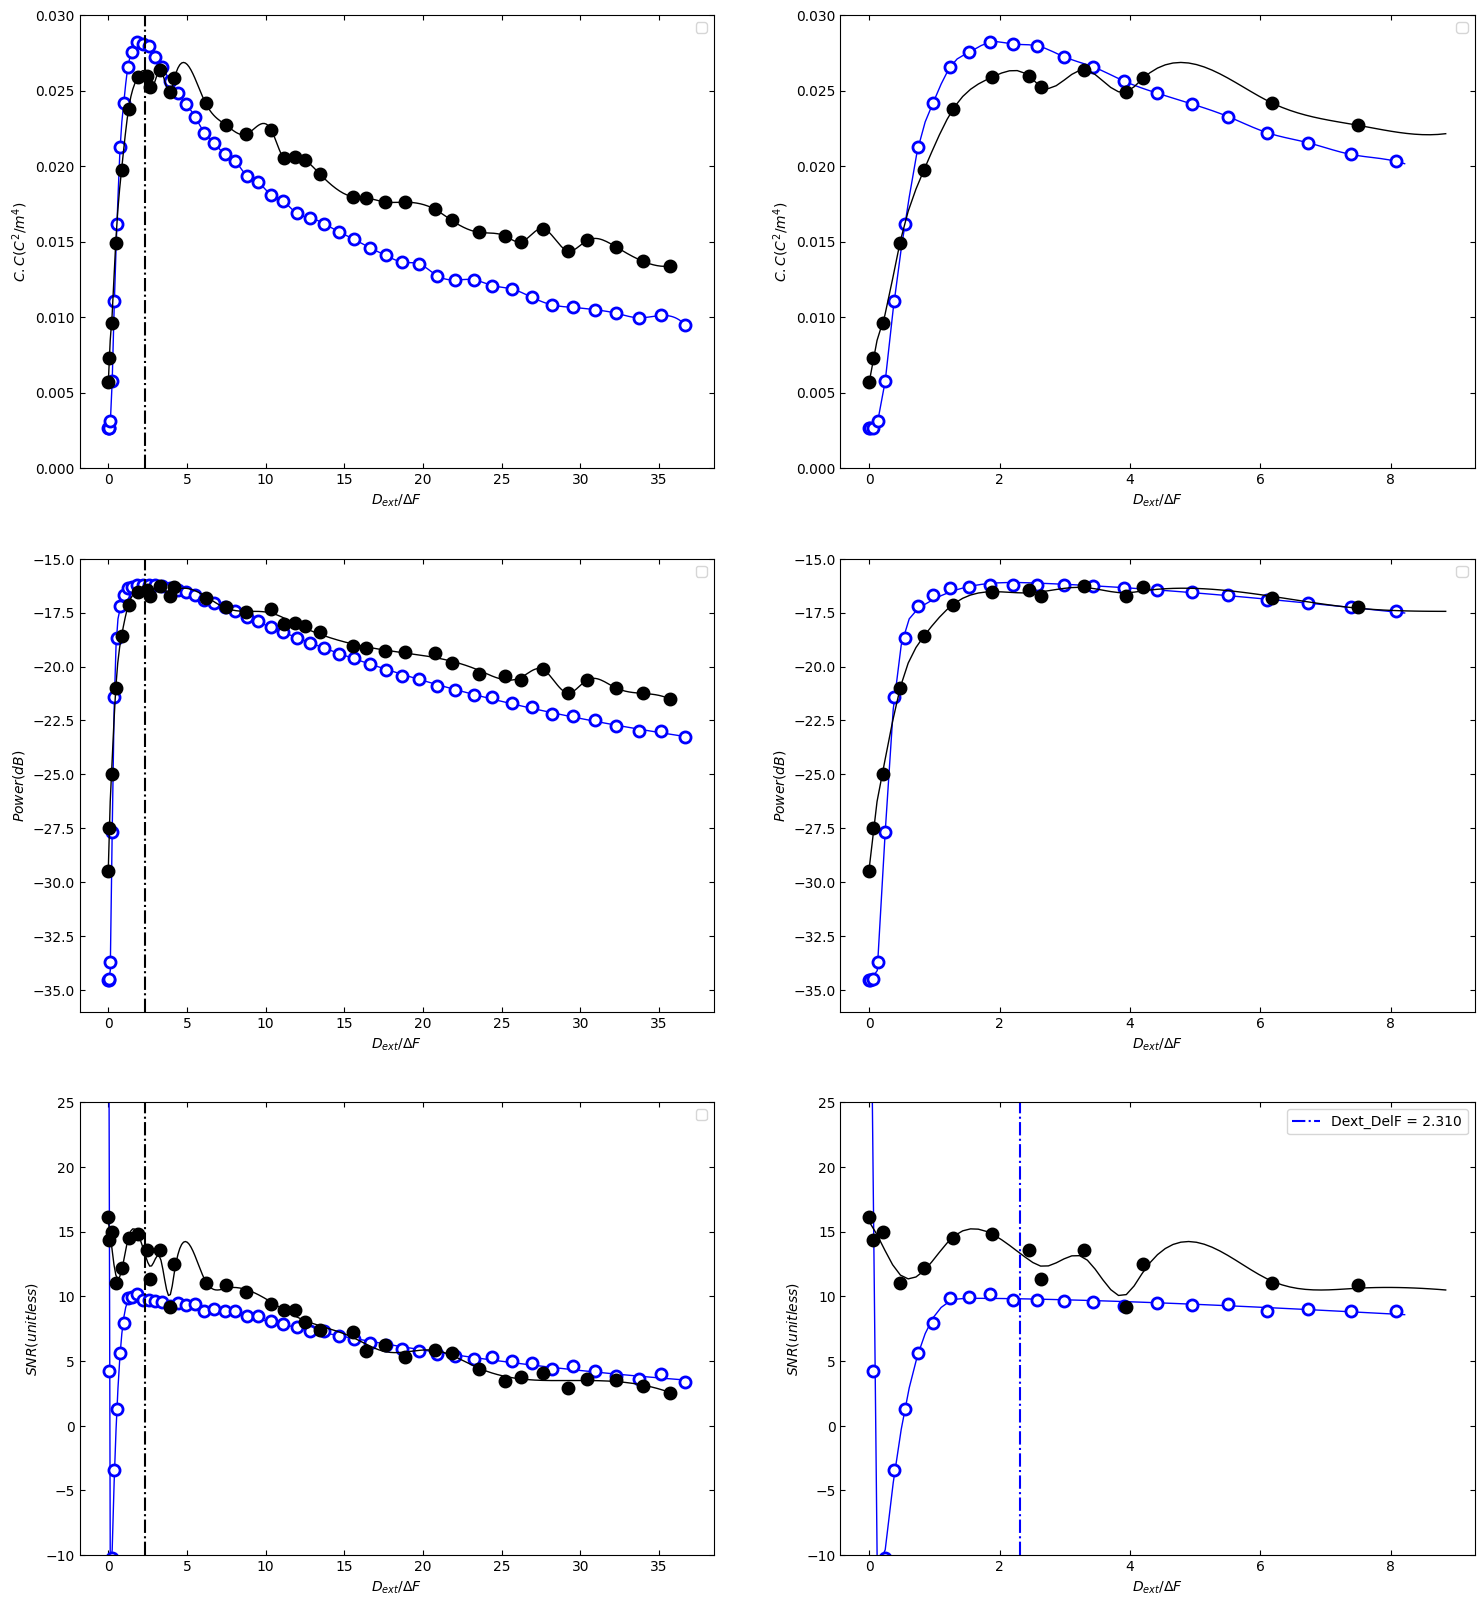

In [21]:
lwth = 1
mwth = 2
ms = 8
clr_sim = "blue"
clr_exp = "black"
styl = "o"

Dext_delF_opt = 2.31

plt.figure(figsize=(18, 20))
plt.subplot(3,2,1)
plt.plot(Dext_delF_smooth, cov_smooth, "-", linewidth = lwth, c = clr_sim)
plt.plot(Dext_delF, COV, styl, linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white', c = clr_sim)
plt.plot(Dext_delF_exp_smooth, cov_exp_smooth, "-", linewidth = lwth, c = clr_exp)
plt.plot(Dext_delF_crt_exp, COV_exp, styl, linewidth = lwth, mew = mwth, markersize=ms, c = clr_exp)
plt.ylim([0, 0.03])

plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$C.C (C^2/m^4)$"); plt.legend()
plt.axvline(x=Dext_delF_opt, color=clr_exp, linestyle='-.', label=f'Dext_DelF = {Dext_delF_opt:.3f}') # Draw vertical line at corresponding SD
plt.tick_params(axis='both', direction='in', top=True, right=True  )

plt.subplot(3,2,3)
plt.plot(Dext_delF_smooth, psr_smooth, "-", linewidth = lwth, c = clr_sim)
plt.plot(Dext_delF, 10*np.log10(PSR), styl, linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white',  c = clr_sim)
plt.plot(Dext_delF_exp_smooth, psr_exp_smooth, "-", linewidth = lwth, c = clr_exp)
plt.plot(Dext_delF_crt_exp, 10*np.log10(PSR_exp), styl, linewidth = lwth, mew = mwth, markersize=ms,  c = clr_exp)
plt.ylim([-36, -15])

plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$Power (dB)$");  plt.legend()
plt.axvline(x=Dext_delF_opt, color=clr_exp, linestyle='-.', label=f'Dext_DelF = {Dext_delF_opt:.3f}') # Draw vertical line at corresponding SD
plt.tick_params(axis='both', direction='in', top=True, right=True)

plt.subplot(3,2,5)
plt.plot(Dext_delF_smooth, snr_smooth, "-", linewidth = lwth, c = clr_sim)
plt.plot(Dext_delF, 10*np.log10(SNR), styl, linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white', c = clr_sim)
plt.plot(Dext_delF_exp_smooth, snr_exp_smooth, "-", linewidth = lwth, c = clr_exp)
plt.plot(Dext_delF_crt_exp, 10*np.log10(SNR_exp), styl, linewidth = lwth, mew = mwth, markersize=ms, c = clr_exp)
plt.ylim([-10, 25])

plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$SNR (unitless)$"); plt.legend()
plt.axvline(x=Dext_delF_opt, color=clr_exp, linestyle='-.', label=f'Dext_DelF = {Dext_delF_opt:.3f}') # Draw vertical line at corresponding SD
plt.tick_params(axis='both', direction='in', top=True, right=True  )


to = 24
to1 = 68
plt.subplot(3,2,2)
plt.plot(Dext_delF_smooth[0:to1], cov_smooth[0:to1], "-", linewidth = lwth, c = clr_sim)
plt.plot(Dext_delF[0:to], COV[0:to],styl, linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white', c = clr_sim)
plt.ylim([0, 0.03])

plt.subplot(3,2,4)
plt.plot(Dext_delF_smooth[0:to1], psr_smooth[0:to1], "-", linewidth = lwth, c = clr_sim)
plt.plot(Dext_delF[0:to], 10*np.log10(PSR[0:to]),styl, linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white', c = clr_sim)
plt.ylim([-36, -15])

plt.subplot(3,2,6)
plt.plot(Dext_delF_smooth[0:to1], snr_smooth[0:to1], "-", linewidth = lwth, c = clr_sim)
plt.plot(Dext_delF[0:to], 10*np.log10(SNR[0:to]),styl, linewidth = lwth, mew = mwth, markersize=ms, markerfacecolor='white',  c = clr_sim)
plt.axvline(x=Dext_delF_opt, color=clr_sim, linestyle='-.', label=f'Dext_DelF = {Dext_delF_opt:.3f}') # Draw vertical line at corresponding SD
plt.ylim([-10, 25])

to = 14
to1 = 75
plt.subplot(3,2,2)
plt.plot(Dext_delF_exp_smooth[0:to1], cov_exp_smooth[0:to1], "-", linewidth = lwth, c = clr_exp)
plt.plot(Dext_delF_crt_exp[0:to], COV_exp[0:to], styl, linewidth = lwth, mew = mwth, markersize=ms, c = clr_exp)
plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$C.C (C^2/m^4)$"); plt.legend()
plt.tick_params(axis='both', direction='in', top=True, right=True  )
plt.subplot(3,2,4)
plt.plot(Dext_delF_exp_smooth[0:to1], psr_exp_smooth[0:to1], "-", linewidth = lwth, c = clr_exp)
plt.plot(Dext_delF_crt_exp[0:to], 10*np.log10(PSR_exp[0:to]), styl, linewidth = lwth, mew = mwth, markersize=ms,  c = clr_exp)
plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$Power (dB)$");  plt.legend()
plt.tick_params(axis='both', direction='in', top=True, right=True  )
plt.subplot(3,2,6)
plt.plot(Dext_delF_exp_smooth[0:to1], snr_exp_smooth[0:to1], "-", linewidth = lwth, c = clr_exp)
plt.plot(Dext_delF_crt_exp[0:to], 10*np.log10(SNR_exp[0:to]), styl, linewidth = lwth, mew = mwth, markersize=ms, c = clr_exp)
plt.xlabel("$D_{ext} / \Delta F$"); plt.ylabel("$SNR (unitless)$"); plt.legend()
plt.tick_params(axis='both', direction='in', top=True, right=True  )

plt.savefig(f"SR_matric_{fsig[0]}hz_rv1.pdf")


Top Row SD = 0.24
Top Row SD = 1.06
Top Row SD = 2.94
Bottom Row SD = 0.3
Bottom Row SD = 1.05
Bottom Row SD = 3.0


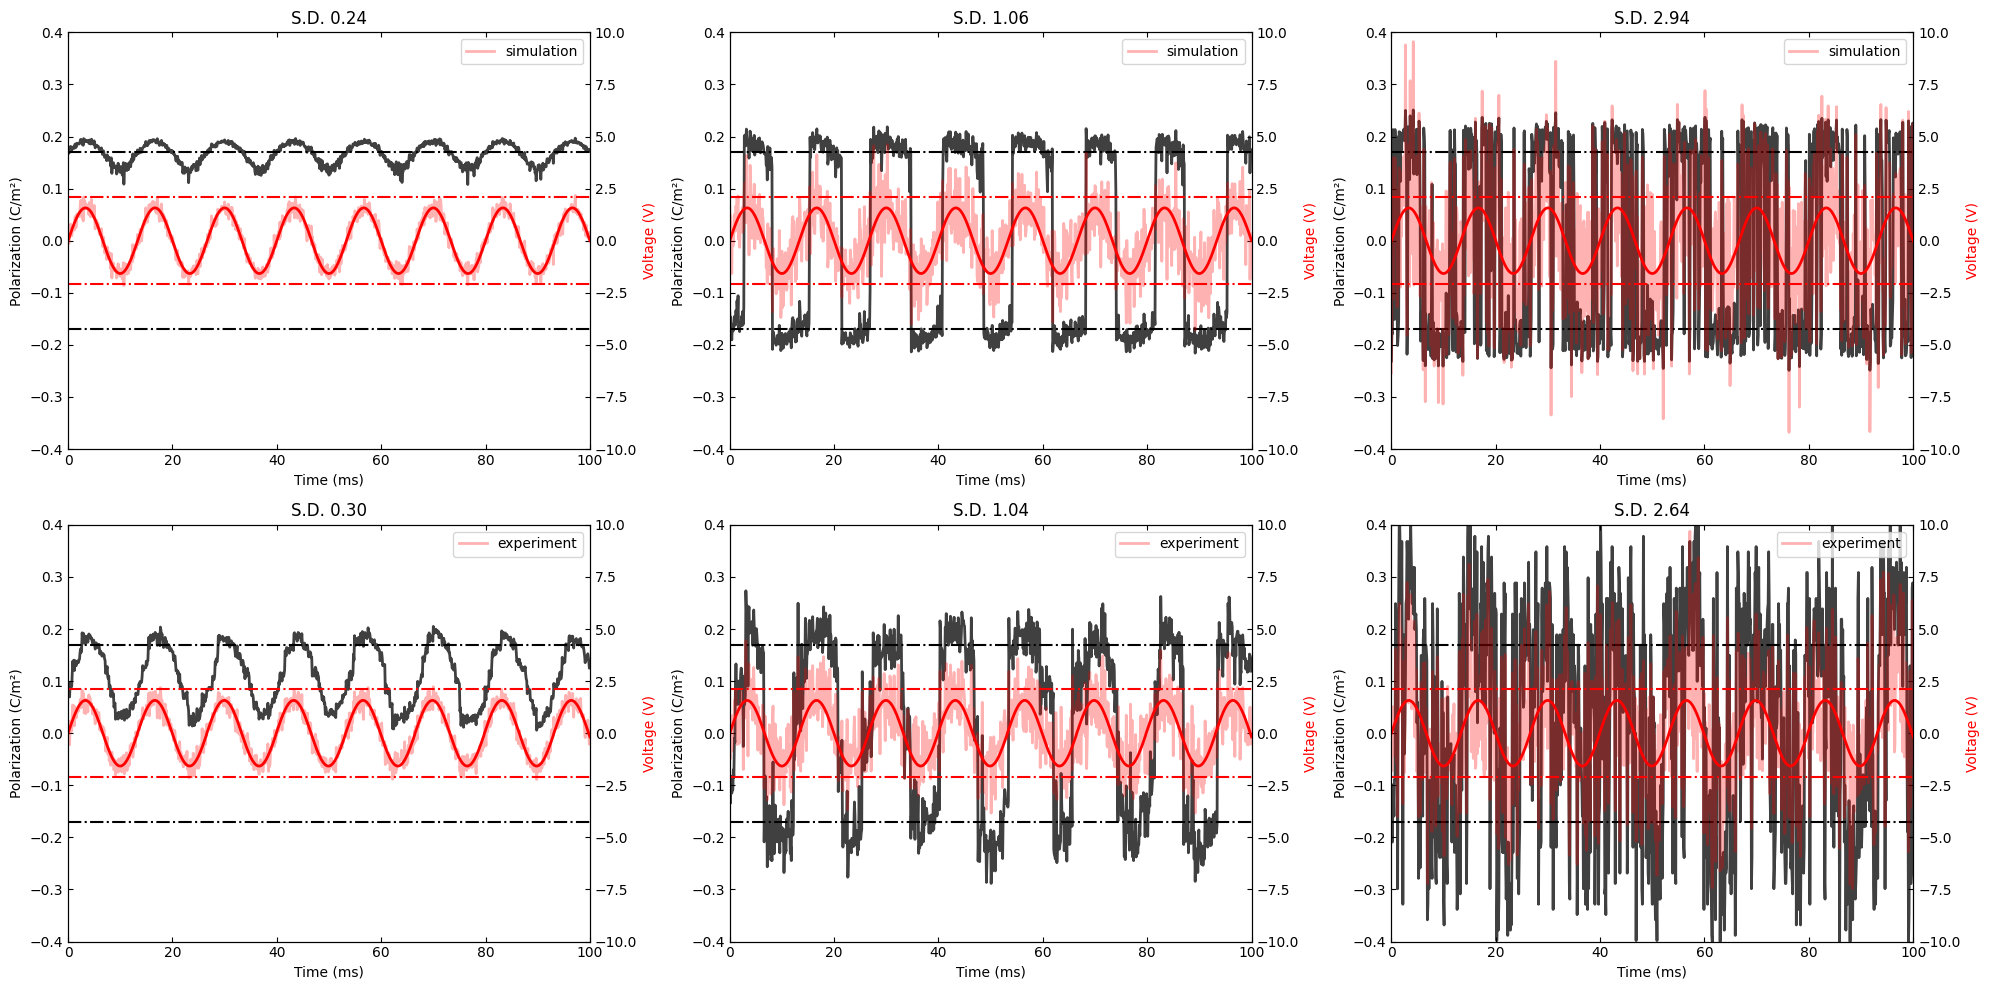

In [22]:
raw_data_file = f"sim_rv1.{fsig[0]}\\raw_data"

sd_values_top = [0.24, 1.06, 2.94]
sd_values_bottom = [0.3, 1.05, 3.0]
clr = ["red", "black"]
lnwidth = [2, 2]
dt_top = 1e-4
dt_bottom = 1e-4
alpha_P = 0.75
alpha_V = 0.3

ncycl_shift_top = 3
ncycl_shift_bottom = 12

fro1_top = ncycl_shift_top * int(1/(fsig[0]*dt_top))
fro1_bottom = int(bw + 48 + ncycl_shift_bottom * int(1/(fsig[0]*dt_top)))

no_cycle = 10

to1_top = int(fro1_top + no_cycle / (100 * dt_top) + 1)
to1_bottom = int(fro1_bottom + no_cycle / (100 * dt_bottom) + 1)

V_range = 10
P_range = 0.4

Vc = 2.1
Pr = 0.17

plt.figure(figsize=(20, 10))
# First row
for e, sd in enumerate(sd_values_top):
    print(f"Top Row SD = {sd}")
    t_data, V_data, P_data = sr.read_tEP_data(raw_data_file + f'\\PE_{fsig[0]}hz_{Asig[0]}V_sd{sd:.2f}_ens{2}.txt')
    t_data, V_data_0, _ = sr.read_tEP_data(raw_data_file + f'\\PE_{fsig[0]}hz_{Asig[0]}V_sd{0:.2f}_ens{2}.txt')

    dt = t_data[1] - t_data[0]
    V_data = V_data[fro1_top:to1_top] * tf
    V_data_0 = V_data_0[fro1_top:to1_top] * tf
    P_data = P_data[fro1_top:to1_top]
    t_data = np.linspace(0, (len(V_data)-1)*dt, len(V_data))*1e3
    V_data = np.clip(V_data, -V_range, V_range)
    P_data = np.clip(P_data, -P_range, P_range)

    ax1 = plt.subplot(2, 3, e+1)
    
    ax1.plot(t_data, P_data, color=clr[1], linewidth =  lnwidth[1], alpha = alpha_P)
    ax1.set_ylim([-P_range, P_range])
    ax1.axhline(y=Pr, linestyle='-.', color=clr[1])
    ax1.axhline(y=-Pr, linestyle='-.', color=clr[1])
    ax1.set_ylabel('Polarization (C/m²)', color=clr[1])
    ax1.set_xlabel('Time (ms)')
    ax1.tick_params(axis='both', direction='in', top=True, right=True)
    
    ax2 = ax1.twinx()

    ax2.plot(t_data, V_data, color=clr[0], linewidth = lnwidth[0], alpha = alpha_V)
    ax2.plot(t_data, V_data_0, color=clr[0], linewidth = lnwidth[0])

    ax2.set_ylim([-V_range, V_range])
    ax2.set_xlim(t_data[0], t_data[-1])
    ax2.axhline(y=Vc, linestyle='-.', color=clr[0])
    ax2.axhline(y=-Vc, linestyle='-.', color=clr[0])
    ax2.set_ylabel('Voltage (V)', color=clr[0])
    ax2.set_xlabel('Time (ms)')
    ax2.set_title(f"S.D. {sd:.2f}")
    ax2.tick_params(axis='both', direction='in', top=True, right=True)
    ax2.legend(["simulation"])

    

# for finding the corrected sd
start_i, end_i = [45, 45, 45], [20067, 17592, 15042] #index of the data
#index after the poling pulse
fro = int(bw + 48)
j = 2
IISc_data_path = '..\\IISc_data\\'
file_path = IISc_data_path + f'new_{fsig[0]}Hz\\0.00.xls'   
t_data, V_data, P_data = load_data(file_path, start_i[j], end_i[j])    
V0 =  V_data[fro:]

# Second row
for e, sd in enumerate(sd_values_bottom):
    print(f"Bottom Row SD = {sd}")
    file_path = IISc_data_path + f'new_{fsig[0]}Hz\\{sd:.2f}.xls'
    P_data, V_data, t_data = load_data(file_path, start_i[j], end_i[j])
    file_path = IISc_data_path + f'new_{fsig[0]}Hz\\{0.00:.2f}.xls'
    _, V_data_0, t_data = load_data(file_path, start_i[j], end_i[j])

    sd_crt_plt =  sr.sd_correction(V_data[fro:],V0)
    # print(f"Corrected SD for plot: {sd_crt_plt}")
    dt = (t_data[1] - t_data[0])
    V_data = V_data[fro1_bottom:to1_bottom]
    V_data_0 = V_data_0[fro1_bottom:to1_bottom]
    P_data = P_data[fro1_bottom:to1_bottom]
    V_data = V_data[::1]
    V_data_0 = V_data_0[::1]
    P_data = P_data[::1]
    t_data = np.linspace(0, (len(V_data)-1)*dt, len(V_data))*1e3
    V_data = np.clip(V_data, -V_range, V_range)
    P_data = np.clip(P_data, -P_range, P_range)

    ax1 = plt.subplot(2, 3, e+4)
    
    ax1.plot(t_data, P_data, color=clr[1], linewidth = lnwidth[1], alpha = alpha_P)
    ax1.set_ylim([-P_range, P_range])
    ax1.axhline(y=Pr, linestyle='-.', color=clr[1])
    ax1.axhline(y=-Pr, linestyle='-.', color=clr[1])
    ax1.set_ylabel('Polarization (C/m²)', color=clr[1])
    ax1.set_xlabel('Time (ms)')
    ax1.tick_params(axis='both', direction='in', top=True, right=True)

    ax2 = ax1.twinx()

    ax2.plot(t_data, V_data, color=clr[0], linewidth = lnwidth[0], alpha = alpha_V)
    ax2.plot(t_data, V_data_0, color=clr[0], linewidth = lnwidth[0])

    ax2.set_ylim([-V_range, V_range])
    ax2.set_xlim(t_data[0], t_data[-1])
    ax2.axhline(y=Vc, linestyle='-.', color=clr[0])
    ax2.axhline(y=-Vc, linestyle='-.', color=clr[0])
    ax2.set_ylabel('Voltage (V)', color=clr[0])
    ax2.set_xlabel('Time (ms)')
    ax2.set_title(f"S.D. {sd_crt_plt:.2f}")
    ax2.tick_params(axis='both', direction='in', top=True, right=True)
    ax2.legend(["experiment"])


plt.tight_layout()
plt.savefig(f"IISc_P_t_data_{fsig[0]}rv1.pdf")
plt.show()
